In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahwagih/mall-customers-segmentation")

print("Path to dataset files:", path)

C:\Users\egorm\PycharmProjects\IntellectualSystemsEngineering\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.56k/1.56k [00:00<00:00, 2.80MB/s]

Extracting files...
Path to dataset files: C:\Users\egorm\.cache\kagglehub\datasets\abdallahwagih\mall-customers-segmentation\versions\1


In [2]:
path

'C:\\Users\\egorm\\.cache\\kagglehub\\datasets\\abdallahwagih\\mall-customers-segmentation\\versions\\1'

In [3]:
import pandas as pd
df = pd.read_csv(f'{path}/Mall_customers.csv')

In [4]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [26]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

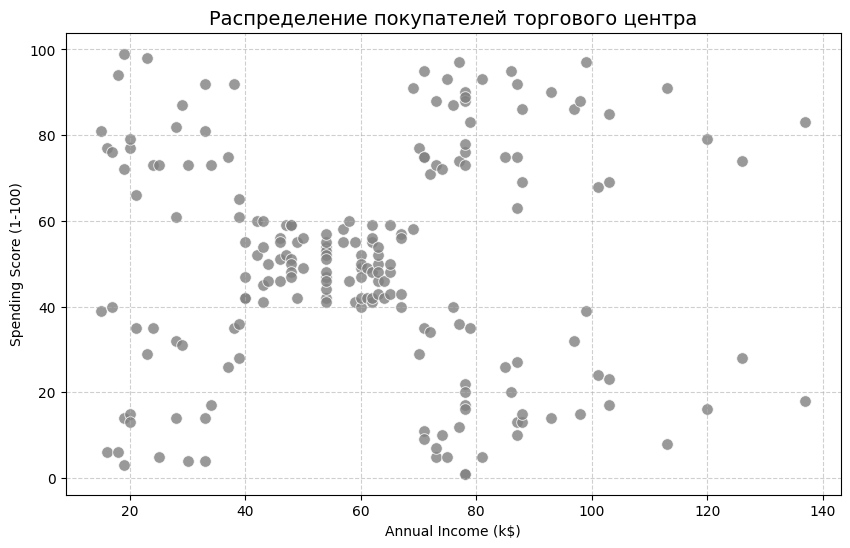

In [9]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
plt.figure(figsize = (10,6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], color='gray', s=70, alpha=0.8)
plt.title('Распределение покупателей торгового центра', fontsize=14)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

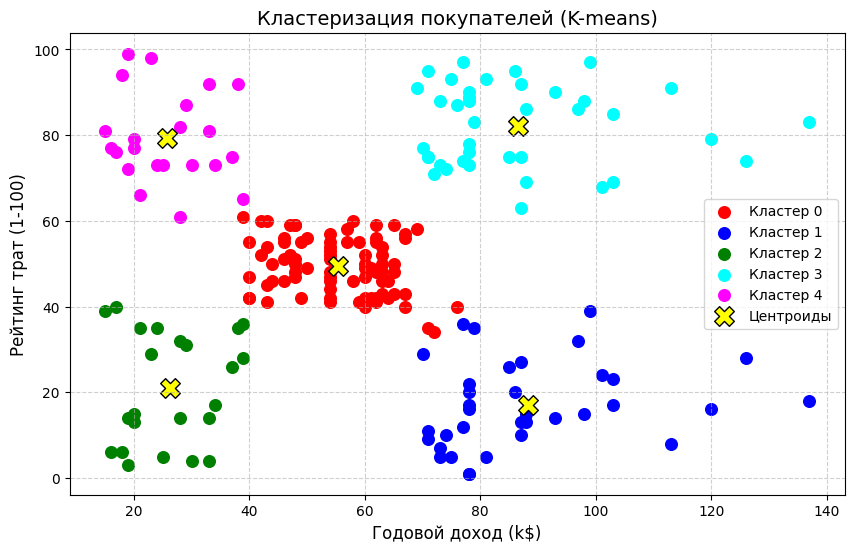

In [10]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, init="k-means++", random_state=1917, n_init=10)
y_kmeans = kmeans.fit_predict(X)
plt.figure(figsize = (10,6))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1],
                s=70, c=colors[i], label=f'Кластер {i}')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='yellow', edgecolors='black', marker='X', label='Центроиды')
plt.title('Кластеризация покупателей (K-means)', fontsize=14)
plt.xlabel('Годовой доход (k$)', fontsize=12)
plt.ylabel('Рейтинг трат (1-100)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [19]:
men = df[df['Genre'] == 'Male']
women = df[df['Genre'] == 'Female']

In [20]:
men

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
8,9,Male,64,19,3
10,11,Male,67,19,14
14,15,Male,37,20,13
...,...,...,...,...,...
187,188,Male,28,101,68
192,193,Male,33,113,8
197,198,Male,32,126,74
198,199,Male,32,137,18


In [22]:
women

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
...,...,...,...,...,...
191,192,Female,32,103,69
193,194,Female,38,113,91
194,195,Female,47,120,16
195,196,Female,35,120,79


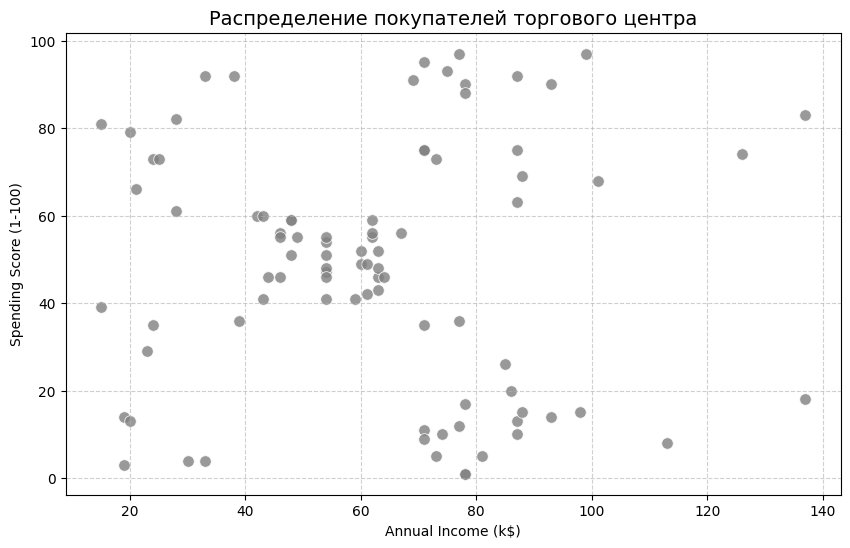

In [23]:
X_men = men[['Annual Income (k$)', 'Spending Score (1-100)']].values
plt.figure(figsize = (10,6))
sns.scatterplot(x=X_men[:, 0], y=X_men[:, 1], color='gray', s=70, alpha=0.8)
plt.title('Распределение покупателей торгового центра', fontsize=14)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

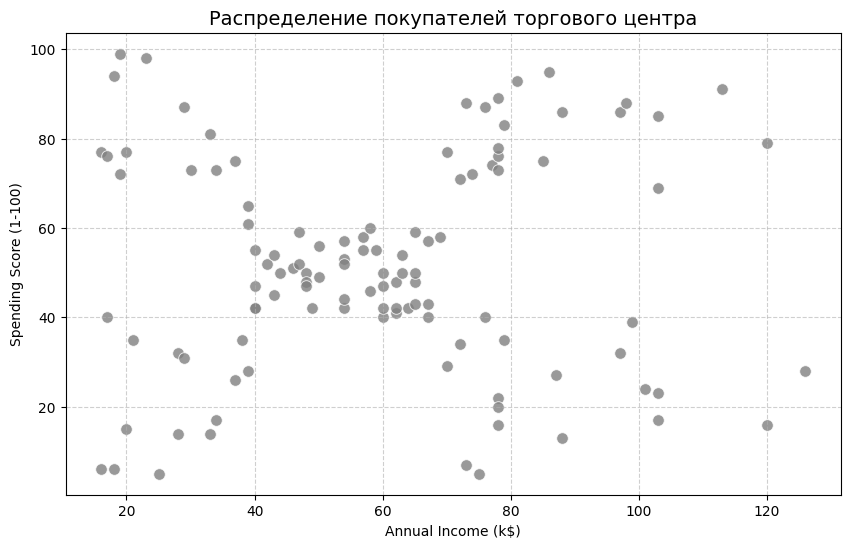

In [24]:
X_women = women[['Annual Income (k$)', 'Spending Score (1-100)']].values
plt.figure(figsize = (10,6))
sns.scatterplot(x=X_women[:, 0], y=X_women[:, 1], color='gray', s=70, alpha=0.8)
plt.title('Распределение покупателей торгового центра', fontsize=14)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

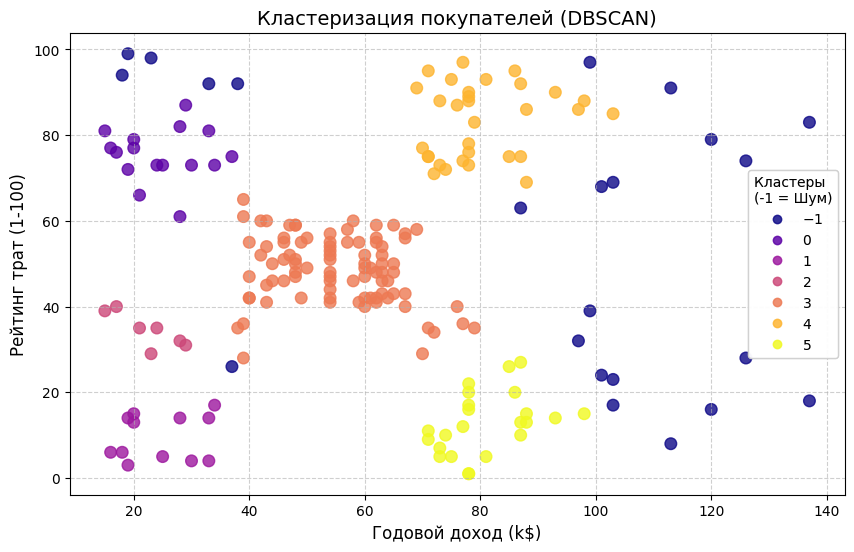

Алгоритм нашел 23 шумовых точек (выбросов).


In [39]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=9, min_samples=5)
y_dbscan = dbscan.fit_predict(X)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_dbscan, cmap='plasma', s=70, alpha=0.8)

plt.title('Кластеризация покупателей (DBSCAN)', fontsize=14)
plt.xlabel('Годовой доход (k$)', fontsize=12)
plt.ylabel('Рейтинг трат (1-100)', fontsize=12)

legend1 = plt.legend(*scatter.legend_elements(), title="Кластеры \n(-1 = Шум)")
plt.gca().add_artist(legend1)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

noise_points = list(y_dbscan).count(-1)
print(f"Алгоритм нашел {noise_points} шумовых точек (выбросов).")

In [40]:
from sklearn.metrics import silhouette_score


sil_kmeans = silhouette_score(X, y_kmeans)
print(f"Индекс Силуэта для K-means: {sil_kmeans:.3f}")

core_mask = y_dbscan != -1
sil_dbscan = silhouette_score(X[core_mask], y_dbscan[core_mask])
print(f"Индекс Силуэта для DBSCAN (без учета шума): {sil_dbscan:.3f}")

Индекс Силуэта для K-means: 0.554
Индекс Силуэта для DBSCAN (без учета шума): 0.557


In [3]:
import pandas as pd
movies = pd.read_csv('../movies.csv', sep=',')
ratings = pd.read_csv('../ratings.csv', sep=',')
df = pd.merge(ratings[ratings['rating'] >= 4.0], movies, on='movieId')[['userId', 'title']].groupby('userId').agg({'title':lambda x: list(x)})
ratings_merged = pd.merge(ratings[ratings['rating'] >= 4.0], movies, on='movieId')
basket = pd.crosstab(ratings_merged['userId'], ratings_merged['title']).astype('bool')
basket

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
607,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
608,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [5]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(basket)
X_reduced

array([[ 5.90850471, -2.34126075],
       [ 0.59563733,  0.78978492],
       [ 0.07071363, -0.04435155],
       ...,
       [ 7.6560691 ,  2.44664714],
       [ 0.53117159, -0.05624997],
       [12.36834803,  6.02036898]], shape=(609, 2))

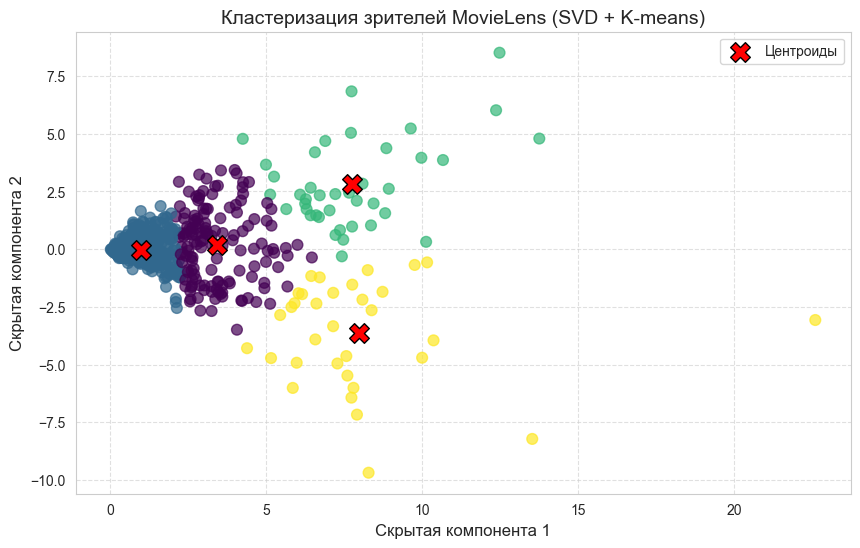

In [8]:
import matplotlib.pyplot as plt
kmeans_svd = KMeans(n_clusters=4, init='k-means++', random_state=1917, n_init=10)
y_kmeans_svd = kmeans_svd.fit_predict(X_reduced)

plt.figure(figsize=(10, 6))

scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_kmeans_svd, cmap='viridis', s=60, alpha=0.7)

centers = kmeans_svd.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', edgecolors='black', label='Центроиды')

plt.title('Кластеризация зрителей MovieLens (SVD + K-means)', fontsize=14)
plt.xlabel('Скрытая компонента 1', fontsize=12)
plt.ylabel('Скрытая компонента 2', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [12]:
from sklearn.metrics import silhouette_score

sil_kmeans_svd = silhouette_score(X_reduced, y_kmeans_svd)
print(f"Индекс Силуэта для K-means: {sil_kmeans_svd:.3f}")

Индекс Силуэта для K-means: 0.499
